<a href="https://colab.research.google.com/github/kuroko941/ml-learning-journey/blob/main/AI4I_2020_Predictive_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
!kaggle datasets download -d stephanmatzka/predictive-maintenance-dataset-ai4i-2020

Dataset URL: https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
License(s): CC-BY-NC-SA-4.0
100% 136k/136k [00:00<00:00, 77.4MB/s]



In [74]:
import zipfile
zip_ref=zipfile.ZipFile('/content/predictive-maintenance-dataset-ai4i-2020.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [75]:
import pandas as pd
import numpy as np

In [76]:
df=pd.read_csv('ai4i2020.csv')

In [77]:
# 0 = no failure, 1 = failure
#L for low, M for medium, and H for high quality
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [78]:
print(df.head())
print('-'*60)
print(df.info())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [79]:

df = df.drop(['UDI','Product ID','TWF','HDF','PWF','OSF','RNF'],
    axis=1)

In [80]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [81]:
df['Machine failure'].value_counts(normalize=True)*100# balance or unbalance

,proportion
Machine failure,
0,96.61
1,3.39


In [82]:
df.isnull().sum()

,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0


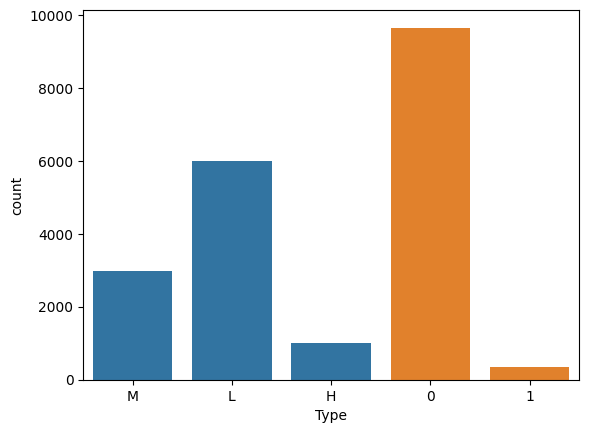

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Type',data=df)
sns.countplot(x='Machine failure',data=df)
plt.show()

<Axes: >

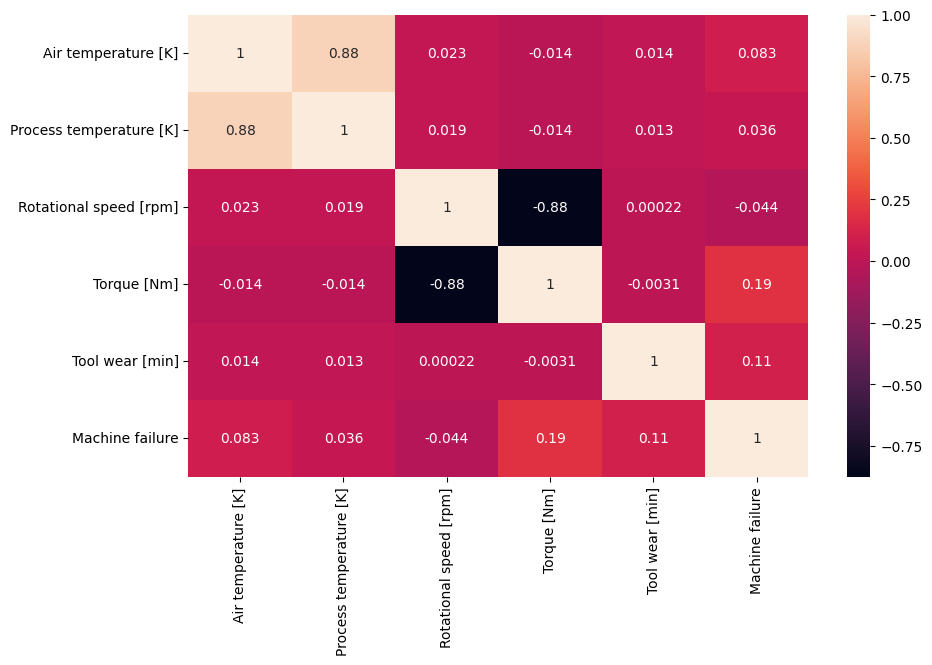

In [84]:
#correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)

In [97]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["Type"] = encoder.fit_transform(df["Type"])

In [99]:
x=df.drop('Machine failure',axis=1)
y=df['Machine failure']

In [100]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)#bcz of imbalance data

In [101]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


# Training model

#1.random forest

In [102]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

#evaluate

In [103]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print('-'*50)
print(classification_report(y_test,y_pred))

[[1923    9]
 [  23   45]]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.83      0.66      0.74        68

    accuracy                           0.98      2000
   macro avg       0.91      0.83      0.86      2000
weighted avg       0.98      0.98      0.98      2000



#2.Logistic Regression

In [104]:
from sklearn.linear_model import LogisticRegression

le=LogisticRegression()
le.fit(x_train,y_train)
y_pred=le.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [105]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print('-'*50)
print(classification_report(y_test,y_pred))

[[1926    6]
 [  59    9]]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.60      0.13      0.22        68

    accuracy                           0.97      2000
   macro avg       0.79      0.56      0.60      2000
weighted avg       0.96      0.97      0.96      2000



#3.Gradientboostclassifier

In [106]:
from sklearn.ensemble import GradientBoostingClassifier

gc=GradientBoostingClassifier()
gc.fit(x_train,y_train)
y_pred=gc.predict(x_test)

In [107]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print('-'*50)
print(classification_report(y_test,y_pred))

[[1923    9]
 [  23   45]]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.83      0.66      0.74        68

    accuracy                           0.98      2000
   macro avg       0.91      0.83      0.86      2000
weighted avg       0.98      0.98      0.98      2000



##result table

In [108]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest','Gradient Boosting'],
    'Recall':[0.13, 0.62, 0.66],
    'F1 Score':[0.22, 0.72, 0.75]
})

print(results.to_markdown(index=False))

| Model               |   Recall |   F1 Score |
|:--------------------|---------:|-----------:|
| Logistic Regression |     0.13 |       0.22 |
| Random Forest       |     0.62 |       0.72 |
| Gradient Boosting   |     0.66 |       0.75 |


## Feature importance

In [109]:
importance=pd.DataFrame({'Feature':x.columns,'Importance':gc.feature_importances_})
importance.sort_values('Importance',ascending=False)

,Feature,Importance
4,Torque [Nm],0.406614
5,Tool wear [min],0.175852
3,Rotational speed [rpm],0.159449
1,Air temperature [K],0.139851
2,Process temperature [K],0.099400
0,Type,0.018834


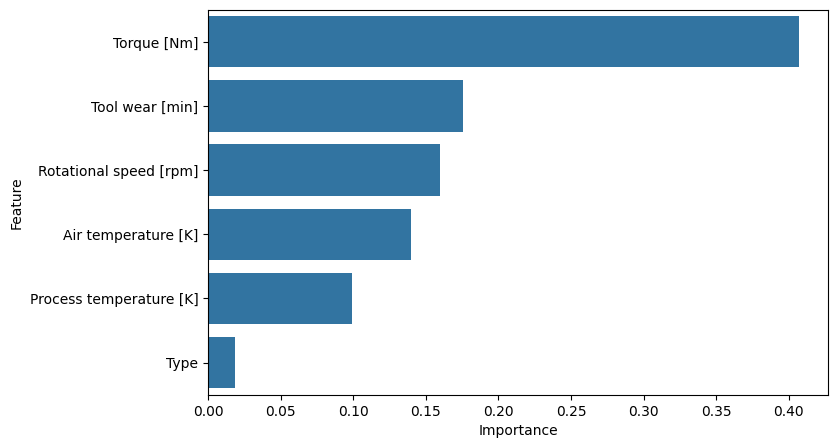

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=importance.sort_values("Importance", ascending=False),
    x="Importance",
    y="Feature"
)
plt.show()

In [111]:
import joblib
joblib.dump(gc,'predictiev_maintainance_model.pkl')
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [112]:
import sklearn
print(sklearn.__version__)

1.6.1
